In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx")

# Filter data
df_filtered = df[
    (df['Earthquake_Magnitude'] >= 4) &
    (df['Rjb_km'] >= 0) & (df['Rjb_km'] <= 500) &
    (df['Vs30_Selected_for_Analysis_m_s'] > 0) &
    (df['Fault_Type'] > 0)
].copy()

print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)


Original shape: (71340, 227)
Filtered shape: (45675, 227)


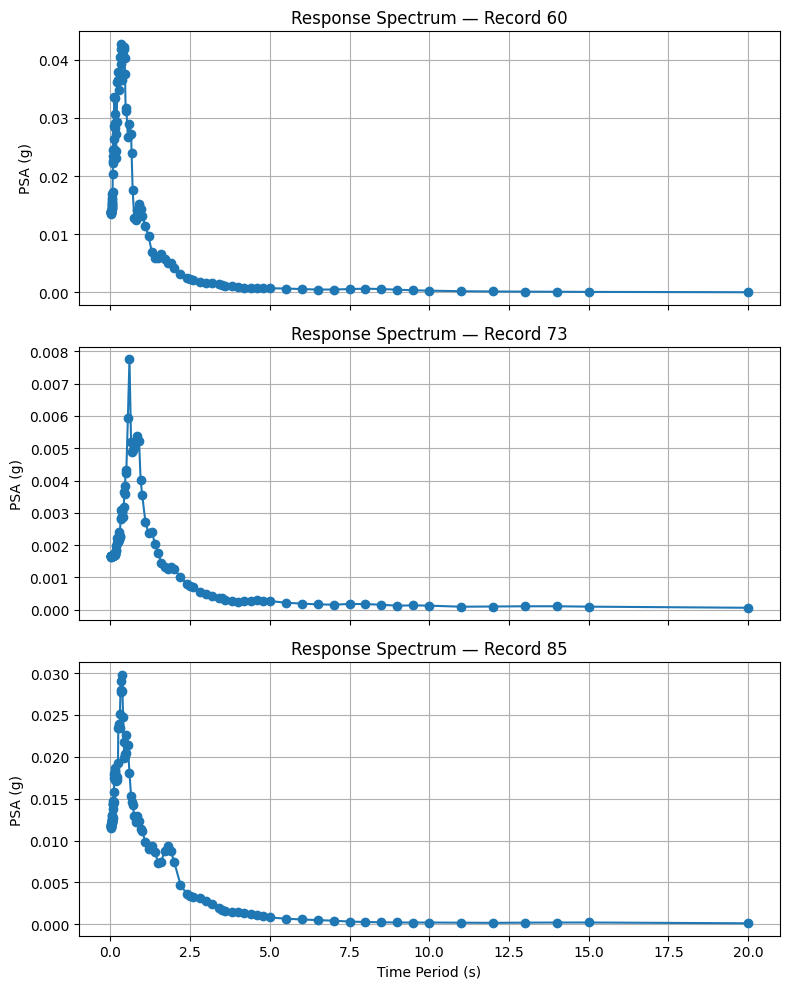

In [2]:
# Identify PSA columns (T-periods)
psa_cols = [col for col in df_filtered.columns if col.startswith('T')]

# Convert column names to numeric time periods
time = [
    float(col.replace("T", "").replace("S", "").replace("pt", "."))
    for col in psa_cols
]

# Select 3 example events
event_indices = [60, 73, 85]

# Plot
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(8, 10), sharex=True)

for ax, idx in zip(axes, event_indices):
    psa_values = df_filtered.loc[idx, psa_cols].values
    ax.plot(time, psa_values, marker='o')
    ax.set_ylabel("PSA (g)")
    ax.set_title(f"Response Spectrum — Record {idx}")
    ax.grid(True)

axes[-1].set_xlabel("Time Period (s)")
plt.tight_layout()
plt.show()


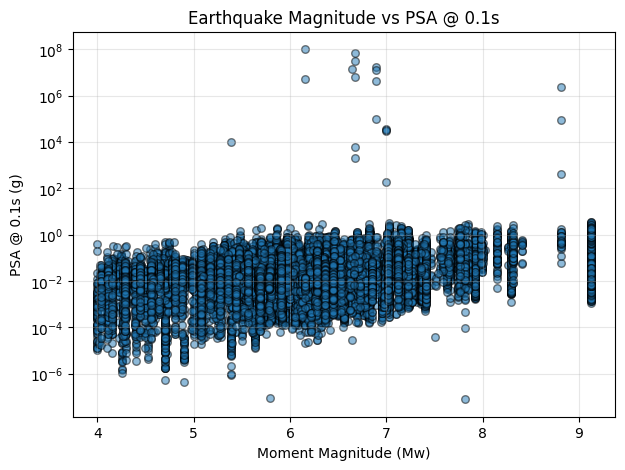

In [3]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_filtered['Earthquake_Magnitude'],
    df_filtered['T0pt100S'],
    alpha=0.5, edgecolors='k', s=30
)

plt.title("Earthquake Magnitude vs PSA @ 0.1s")
plt.xlabel("Moment Magnitude (Mw)")
plt.ylabel("PSA @ 0.1s (g)")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.show()


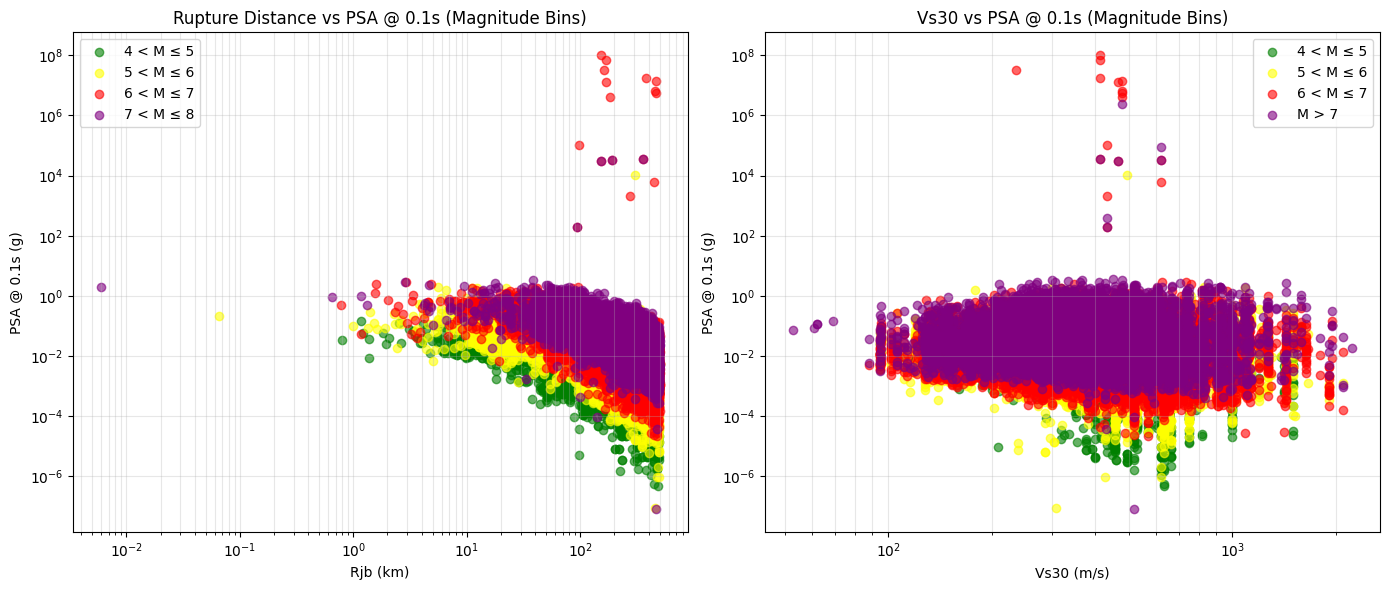

In [4]:
bins_R = [
    {'range': (4, 5), 'color': 'green', 'label': '4 < M ≤ 5'},
    {'range': (5, 6), 'color': 'yellow', 'label': '5 < M ≤ 6'},
    {'range': (6, 7), 'color': 'red', 'label': '6 < M ≤ 7'},
    {'range': (7, 8), 'color': 'purple', 'label': '7 < M ≤ 8'}
]

bins_Vs = [
    {'range': (4, 5), 'color': 'green', 'label': '4 < M ≤ 5'},
    {'range': (5, 6), 'color': 'yellow', 'label': '5 < M ≤ 6'},
    {'range': (6, 7), 'color': 'red', 'label': '6 < M ≤ 7'},
    {'range': (7, 9.5), 'color': 'purple', 'label': 'M > 7'}
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- Rupture vs PSA ----
for b in bins_R:
    mask = df_filtered['Earthquake_Magnitude'].between(*b['range'])
    ax1.scatter(
        df_filtered.loc[mask, 'Rjb_km'],
        df_filtered.loc[mask, 'T0pt100S'],
        color=b['color'], label=b['label'], alpha=0.6
    )

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title("Rupture Distance vs PSA @ 0.1s (Magnitude Bins)")
ax1.set_xlabel("Rjb (km)")
ax1.set_ylabel("PSA @ 0.1s (g)")
ax1.legend()
ax1.grid(True, which="both", alpha=0.3)

# ---- Vs30 vs PSA ----
for b in bins_Vs:
    mask = df_filtered['Earthquake_Magnitude'].between(*b['range'])
    ax2.scatter(
        df_filtered.loc[mask, 'Vs30_Selected_for_Analysis_m_s'],
        df_filtered.loc[mask, 'T0pt100S'],
        color=b['color'], label=b['label'], alpha=0.6
    )

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Vs30 vs PSA @ 0.1s (Magnitude Bins)")
ax2.set_xlabel("Vs30 (m/s)")
ax2.set_ylabel("PSA @ 0.1s (g)")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
df_filtered = df_filtered[
    (df_filtered['Earthquake_Magnitude'] >= 4) & 
    (df_filtered['Rjb_km'] > 0) & 
    (df_filtered['Vs30_Selected_for_Analysis_m_s'] > 0) &
    (df_filtered['Hypocenter_Depth_km'] > 0) &
    (df_filtered['PGA_g'] > 0) & 
    (df_filtered['T0pt100S'] > 0)
]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Create consistent log-transformed predictors
df_filtered['log_Rjb']   = np.log(df_filtered['Rjb_km'])
df_filtered['log_Vs30']  = np.log(df_filtered['Vs30_Selected_for_Analysis_m_s'])
df_filtered['log_Depth'] = np.log(df_filtered['Hypocenter_Depth_km'])

# Predictor matrix (same for both models)
X = df_filtered[['Earthquake_Magnitude',
                 'log_Rjb',
                 'log_Vs30',
                 'log_Depth']]


In [7]:
# ---------- MODEL 1: Predict PSA @ 0.1s ----------

y_psa = np.log(df_filtered['T0pt100S'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_psa, test_size=0.2, random_state=42
)

model_psa = LinearRegression()
model_psa.fit(X_train, y_train)

# Coefficients
coef_psa = pd.DataFrame(
    model_psa.coef_,
    index=X.columns,
    columns=['Coefficient_for_ln(PSA)']
)
print("\n=== Linear Regression Coefficients (PSA) ===")
print(coef_psa)

# Predictions & metrics
y_pred_psa = model_psa.predict(X_test)

print("\nPSA Model Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_psa))
print("R² :", r2_score(y_test, y_pred_psa))



=== Linear Regression Coefficients (PSA) ===
                      Coefficient_for_ln(PSA)
Earthquake_Magnitude                 0.966806
log_Rjb                             -1.528140
log_Vs30                            -0.413073
log_Depth                            0.159228

PSA Model Performance:
MSE: 1.475745070296286
R² : 0.4944909015153166


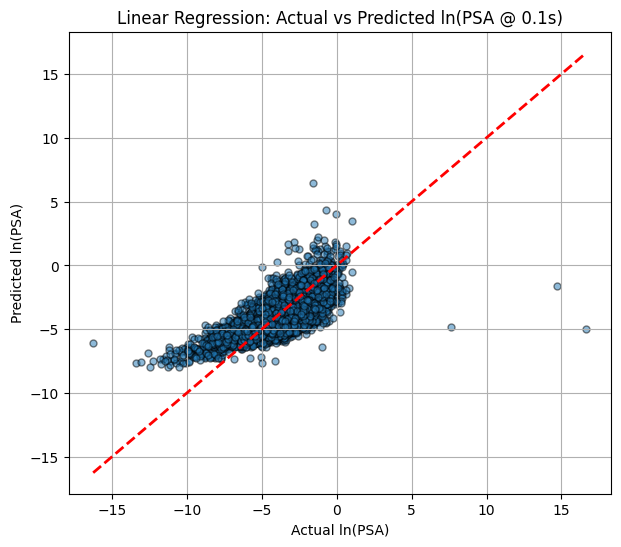

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_psa, alpha=0.5, edgecolors='k', s=25)

# 1:1 line
minv, maxv = min(y_test.min(), y_pred_psa.min()), max(y_test.max(), y_pred_psa.max())
plt.plot([minv, maxv], [minv, maxv], 'r--', lw=2)

plt.title("Linear Regression: Actual vs Predicted ln(PSA @ 0.1s)")
plt.xlabel("Actual ln(PSA)")
plt.ylabel("Predicted ln(PSA)")
plt.grid(True)
plt.show()


In [9]:
# ---------- MODEL 2: Predict PGA ----------

y_pga = np.log(df_filtered['PGA_g'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_pga, test_size=0.2, random_state=42
)

model_pga = LinearRegression()
model_pga.fit(X_train, y_train)

# Coefficients
coef_pga = pd.DataFrame(
    model_pga.coef_,
    index=X.columns,
    columns=['Coefficient_for_ln(PGA)']
)
print("\n=== Linear Regression Coefficients (PGA) ===")
print(coef_pga)

# Predictions & metrics
y_pred_pga = model_pga.predict(X_test)

print("\nPGA Model Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_pga))
print("R² :", r2_score(y_test, y_pred_pga))



=== Linear Regression Coefficients (PGA) ===
                      Coefficient_for_ln(PGA)
Earthquake_Magnitude                 0.998295
log_Rjb                             -1.443750
log_Vs30                            -0.621767
log_Depth                            0.115041

PGA Model Performance:
MSE: 1.1221701900567802
R² : 0.5589670485215592


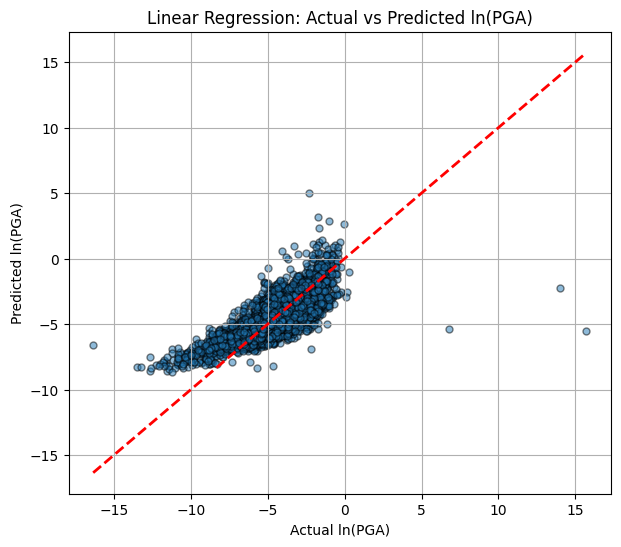

In [10]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_pga, alpha=0.5, edgecolors='k', s=25)

# 1:1 line
minv, maxv = min(y_test.min(), y_pred_pga.min()), max(y_test.max(), y_pred_pga.max())
plt.plot([minv, maxv], [minv, maxv], 'r--', lw=2)

plt.title("Linear Regression: Actual vs Predicted ln(PGA)")
plt.xlabel("Actual ln(PGA)")
plt.ylabel("Predicted ln(PGA)")
plt.grid(True)
plt.show()


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models


# Filter data to ensure valid numbers for log transformations 
df_fil = df_filtered[
    (df_filtered['Earthquake_Magnitude'] >= 4) & (df_filtered['Rjb_km'] > 0) & 
    (df_filtered['Vs30_Selected_for_Analysis_m_s'] > 0) & (df_filtered['Hypocenter_Depth_km'] > 0) &
    (df_filtered['PGA_g'] > 0) & (df_filtered['T0pt100S'] > 0)
].copy()

# 2. Define Inputs (X) and Outputs (y) 
X = pd.DataFrame()
X['M'] = df_fil['Earthquake_Magnitude']
X['logR'] = np.log10(df_fil['Rjb_km'])
X['logVs'] = np.log10(df_fil['Vs30_Selected_for_Analysis_m_s'])
X['Focal'] = df_fil['Hypocenter_Depth_km']

# Targets: Predicting the natural log of shaking 
y = np.log(df_fil[['PGA_g', 'T0pt100S']])

# 3. Split and Scale Data
# 80% for training, 20% for testing the model's accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build the ANN Architecture
model = models.Sequential([
    layers.Input(shape=(4,)), # 4 inputs: M, logR, logVs, Focal 
    layers.Dense(64, activation='relu'), # First hidden layer
    layers.Dense(32, activation='relu'), # Second hidden layer
    layers.Dense(2) # Output layer: 2 neurons for PGA and PSA@0.1s 
])

# 5. Compile and Train
model.compile(optimizer='adam', loss='mse') # Mean Squared Error minimizes prediction gaps

print("Training the ANN...")
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, verbose=0)

# 6. Visualization: Training Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', color='pink')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('ANN Training ')
plt.xlabel('<- Epochs ->')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, ls='--')
plt.show()

# 7. Evaluate
predictions = model.predict(X_test_scaled)
print(f"Model Training Complete. Final Loss: {history.history['loss'][-1]:.4f}")

Training the ANN...


KeyboardInterrupt: 

285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step


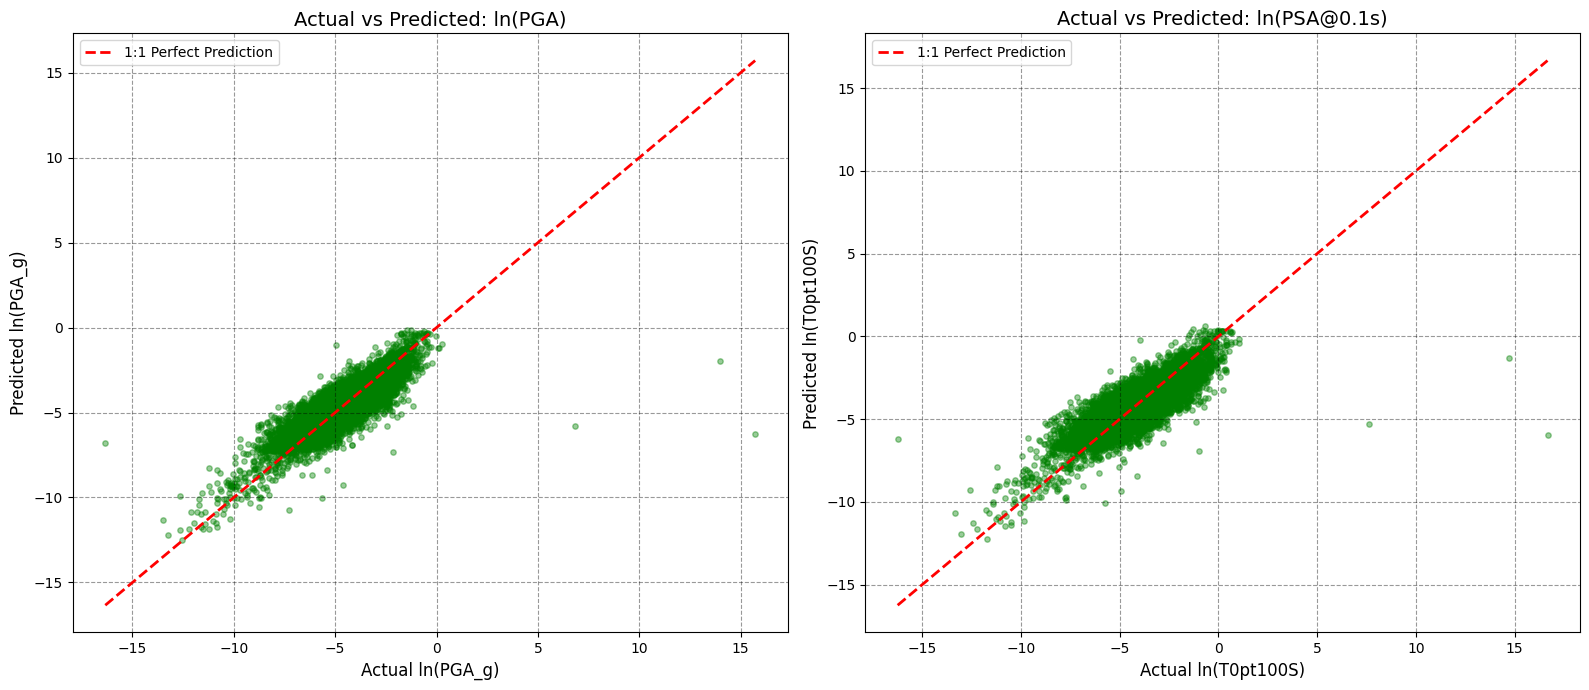

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate Predictions
# We use the scaled test data to get the model's predictions
predictions = model.predict(X_test_scaled)

# 2. Create the Visualization Layout
# We create two subplots: one for PGA and one for PSA@0.1s
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Define labels and targets for iteration
targets = ['PGA_g', 'T0pt100S']
titles = ['Actual vs Predicted: ln(PGA)', 'Actual vs Predicted: ln(PSA@0.1s)']

for i in range(2):
    # Actual values from the test set
    actual = y_test.iloc[:, i]
    # Predicted values from the ANN
    predicted = predictions[:, i]
    
    # Scatter plot
    ax[i].scatter(actual, predicted, alpha=0.4, s=15, color='green', edgecolors='green')
    
    # Add a 1:1 Identity Line (The "Perfect Model" Line)
    # If a point is on this line, the prediction is exactly equal to the actual value.
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Perfect Prediction')
    
    # Formatting
    ax[i].set_title(titles[i], fontsize=14)
    ax[i].set_xlabel(f'Actual ln({targets[i]})', fontsize=12)
    ax[i].set_ylabel(f'Predicted ln({targets[i]})', fontsize=12)
    ax[i].grid(True, which="both", ls="--", alpha=0.4,color='black')
    ax[i].legend()

plt.tight_layout()
plt.show()